In [1]:
import torch
import torch.nn as nn
print(torch.__version__)

2.10.0


In [2]:
from RideSharing import DynamicPricingEnv
env = DynamicPricingEnv()
print("works")

works


/Users/anirudhvuppala/Sem6/RL/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/anirudhvuppala/Sem6/RL/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [3]:
x, _ = env.reset()
print("passenger info:", x[0])
print("driver info:", x[1])
print("No of drivers in time slot:", len(x[1]))
print("no of passengers in le time slot: ", len(x[0]))

passenger info: [0.97070312 0.55078125 0.02734375 0.03320312 0.7507156 ]
driver info: (array([0.8984375 , 0.50390625, 1.86334492]), array([0.9375    , 0.52734375, 1.98108346]), array([0.89648438, 0.59375   , 2.50268162]), array([0.875     , 0.50195312, 0.93244714]), array([0.90429688, 0.52539062, 0.38951354]), array([0.98632812, 0.63085938, 2.2790838 ]))
No of drivers in time slot: 6
no of passengers in le time slot:  5


In [4]:
import numpy as np
action = np.random.uniform(0, 1)
next_x, reward, done, truncated, info = env.step(action)
print("action (price) :", action)
print("reward:", reward)

action (price) : 0.6666299143979139
reward: 0.0


In [5]:
def get_closest_driver(passenger_info, driver_info):
    passenger_loc = passenger_info[:2]  # just x, y of passenger origin
    
    min_dist = float('inf')
    closest_driver = None
    
    for driver in driver_info:
        driver_loc = driver[:2]  # just x, y of driver
        # simple euclidean distance for now
        dist = np.sqrt((passenger_loc[0] - driver_loc[0])**2 + 
                      (passenger_loc[1] - driver_loc[1])**2)
        if dist < min_dist:
            min_dist = dist
            closest_driver = driver
    
    return closest_driver

# test it
passenger_info = x[0]
driver_info = x[1]
closest = get_closest_driver(passenger_info, driver_info)
print("Closest driver:", closest)

Closest driver: [0.9375     0.52734375 1.98108346]


In [6]:
print("info: ", x, len(x))


info:  (array([0.97070312, 0.55078125, 0.02734375, 0.03320312, 0.7507156 ]), (array([0.8984375 , 0.50390625, 1.86334492]), array([0.9375    , 0.52734375, 1.98108346]), array([0.89648438, 0.59375   , 2.50268162]), array([0.875     , 0.50195312, 0.93244714]), array([0.90429688, 0.52539062, 0.38951354]), array([0.98632812, 0.63085938, 2.2790838 ]))) 2


In [7]:
#feature eng
def extract_features(x):
    passenger = x[0].copy()  # copy so we don't modify original
    closest_driver = get_closest_driver(passenger, x[1]).copy()
    
    all_sens = [d[2] for d in x[1]]
    min_sens = np.min(all_sens)
    mean_sens = np.mean(all_sens)
    
    # normalize sensitivities to 0-1 range (max sensitivity ~3.0)
    passenger[4] = passenger[4] / 3.0
    closest_driver[2] = closest_driver[2] / 3.0
    min_sens = min_sens / 3.0
    mean_sens = mean_sens / 3.0
    
    feature = np.concatenate([passenger, closest_driver, 
                              np.array([min_sens]), np.array([mean_sens])])
    return feature

x, _ = env.reset()
features = extract_features(x)
print("feature:", features)
print("feature size:", len(features))

feature: [0.05078125 0.05664062 0.91015625 0.65429688 0.36422609 0.03515625
 0.03320312 0.83062311 0.11965317 0.47513814]
feature size: 10


In [22]:
class PolicyNetwork(nn.Module):
    def __init__(self):
        super(PolicyNetwork, self).__init__()
        self.layer1 = nn.Linear(10, 64)
        self.layer2 = nn.Linear(64, 64)
        
        self.layer3 = nn.Linear(64, 1)
        self.eta = nn.Parameter(torch.tensor(0.0)) 
    
    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        
        mu = self.layer3(x)
        sigma = torch.exp(self.eta)
        return mu, sigma

In [23]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.constant_(m.bias, 0.1)

model = PolicyNetwork()
model.apply(init_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [24]:
def compute_loss(model, features, reward, baseline, sigma=0.3):
    features_tensor = torch.FloatTensor(features)
    mu = model(features_tensor)
    
    
    dist = torch.distributions.Normal(mu, sigma)
    
    # sample
    u_sample = dist.rsample()  
    a = torch.sigmoid(u_sample)
    
    # correct log prob with jacobian
    log_prob = dist.log_prob(u_sample) - torch.log(a * (1 - a) + 1e-6)
    
    adv = reward - baseline
    loss = -(adv * log_prob)
    
    return loss, a.detach().item()

In [25]:
def train(episodes=100):
    # the train fn
    baseline = 0
    beta = 0.99  # cuz it shd be close to 1
    all_rewards = []

    for episode in range(episodes):
        x, _ = env.reset()
        episode_rewards = []
        episode_log_probs = []

        # collect full trajectory
        for t in range(env.Horizon):
            features = extract_features(x)
            features_tensor = torch.FloatTensor(features)
            mu, sigma = model(features_tensor)  # sigma is now learned
            dist = torch.distributions.Normal(mu, sigma)
            u_sample = dist.rsample()
            a = torch.sigmoid(u_sample)
            
            # log prob with jacobian correction
            log_prob = dist.log_prob(u_sample) - torch.log(a * (1 - a) + 1e-6)
            x, reward, done, truncated, info = env.step(a.detach().item())
            episode_rewards.append(reward)
            episode_log_probs.append(log_prob)

        # single episodic update
        adv = torch.FloatTensor(np.array(episode_rewards) - baseline)
        log_probs_tensor = torch.stack(episode_log_probs).squeeze()
        episode_loss = -(adv * log_probs_tensor).sum()

        # update baseline
        for r in episode_rewards:
            baseline = beta * baseline + (1 - beta) * r

        optimizer.zero_grad()
        episode_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        all_rewards.extend(episode_rewards)
        print(f"episode {episode+1}/{episodes} | avg reward: {np.mean(episode_rewards):.4f}")

    return all_rewards

In [12]:
all_rewards = train(episodes=2)
print("doneeee")
print("total no of timesteps:", len(all_rewards))

episode 1/2 | avg reward: 0.0149
episode 2/2 | avg reward: 0.0151
doneeee
total no of timesteps: 1440


In [13]:
import matplotlib.pyplot as plt

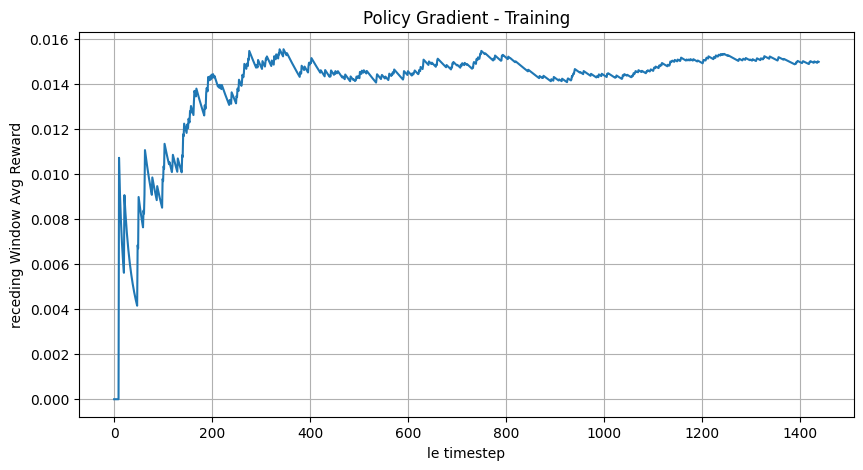

In [14]:
def plot_rewards(all_rewards, window=2000):
    smoothed = []
    for i in range(len(all_rewards)):
        start = max(0, i - window + 1)
        smoothed.append(np.mean(all_rewards[start:i+1]))
    
    plt.figure(figsize=(10, 5))
    plt.plot(smoothed)
    plt.xlabel("le timestep")
    plt.ylabel("receding Window Avg Reward")
    plt.title("Policy Gradient - Training")
    plt.grid(True)
    plt.show()

plot_rewards(all_rewards)

In [26]:
import numpy as np
def test_passenger_sens():
    base_context = np.array([0.5, 0.5, 0.8, 0.8, 0.5])
    driver = np.array([0.4, 0.4, 1.0])

    sens = np.linspace(0.5, 3.0, 20)
    prices = []

    for s in sens:
        base_context[4] = s

        features = np.concatenate([base_context, driver, np.array([1.0]), np.array([1.0])])

        features_tensor = torch.FloatTensor(features)

        with torch.no_grad():
            mu, sigma = model(features_tensor)
            a = torch.sigmoid(mu)

        prices.append(a.item())

    plt.figure(figsize=(8, 5))
    plt.plot(sens, prices)
    plt.xlabel("passenger price sens.")
    plt.ylabel("price set")
    plt.title("Test 1 - price and passenger sensitivity")
    plt.grid(True)
    plt.savefig('test1_passenger_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return prices

In [27]:
def test_driver_sens():
    passenger = np.array([0.5, 0.5, 0.8, 0.8, 1.5]) 
    base_driver = np.array([0.4, 0.4, 0.0])  
    
    sens = np.linspace(0.1, 3.0, 20)
    prices = []
    
    for s in sens:
        base_driver[2] = s  
        features = np.concatenate([passenger, base_driver, np.array([1.0]), np.array([1.0])])
        features_tensor = torch.FloatTensor(features)
        with torch.no_grad():
            mu, sigma = model(features_tensor)
            a = torch.sigmoid(mu)
        prices.append(a.item())
    
    plt.figure(figsize=(8, 5))
    plt.plot(sens, prices)
    plt.xlabel("driver price sens.")
    plt.ylabel("price set")
    plt.title("Test 2 - price and driver sensitivity")
    plt.grid(True)
    plt.savefig('test2_driver_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return prices

In [17]:
model = PolicyNetwork()
model.apply(init_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

episode 1/50 | avg reward: 0.0128
episode 2/50 | avg reward: 0.0139
episode 3/50 | avg reward: 0.0130
episode 4/50 | avg reward: 0.0142
episode 5/50 | avg reward: 0.0157
episode 6/50 | avg reward: 0.0163
episode 7/50 | avg reward: 0.0154
episode 8/50 | avg reward: 0.0164
episode 9/50 | avg reward: 0.0161
episode 10/50 | avg reward: 0.0163
episode 11/50 | avg reward: 0.0182
episode 12/50 | avg reward: 0.0168
episode 13/50 | avg reward: 0.0156
episode 14/50 | avg reward: 0.0161
episode 15/50 | avg reward: 0.0160
episode 16/50 | avg reward: 0.0147
episode 17/50 | avg reward: 0.0156
episode 18/50 | avg reward: 0.0147
episode 19/50 | avg reward: 0.0153
episode 20/50 | avg reward: 0.0159
episode 21/50 | avg reward: 0.0151
episode 22/50 | avg reward: 0.0153
episode 23/50 | avg reward: 0.0137
episode 24/50 | avg reward: 0.0163
episode 25/50 | avg reward: 0.0157
episode 26/50 | avg reward: 0.0155
episode 27/50 | avg reward: 0.0166
episode 28/50 | avg reward: 0.0141
episode 29/50 | avg reward: 0

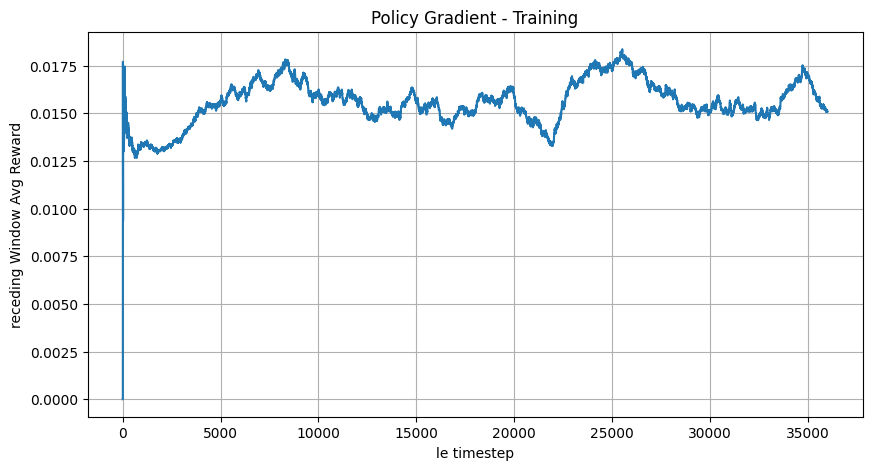

In [136]:
all_rewards = train(episodes=50)
plot_rewards(all_rewards)

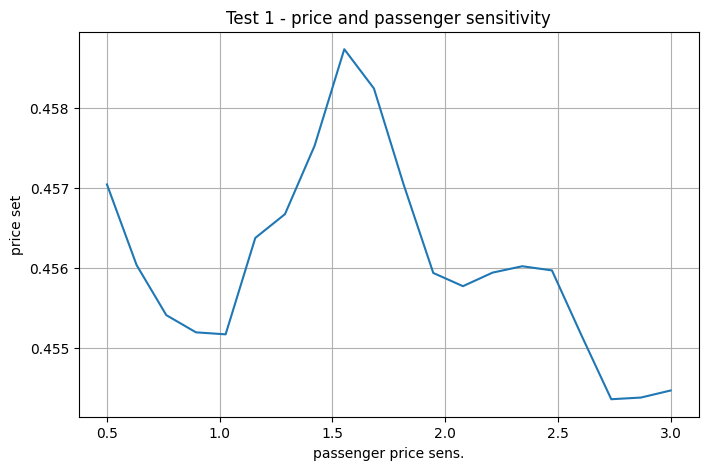

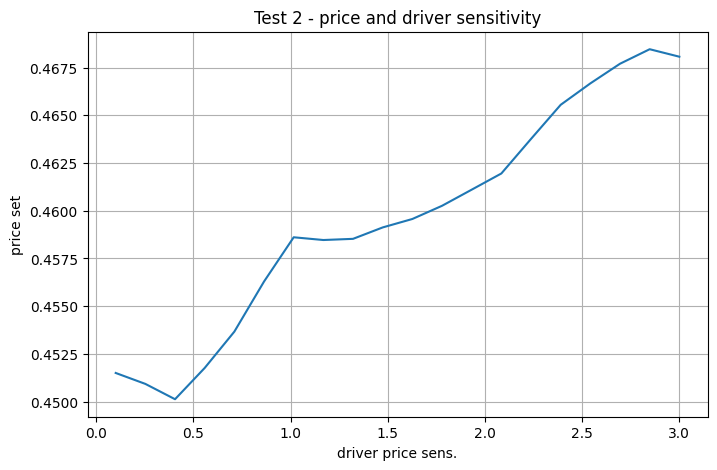

In [18]:
prices_passenger = test_passenger_sens()
prices_driver = test_driver_sens()

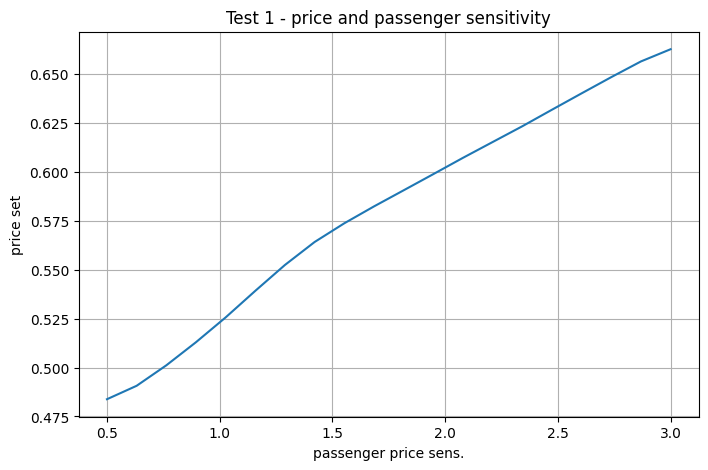

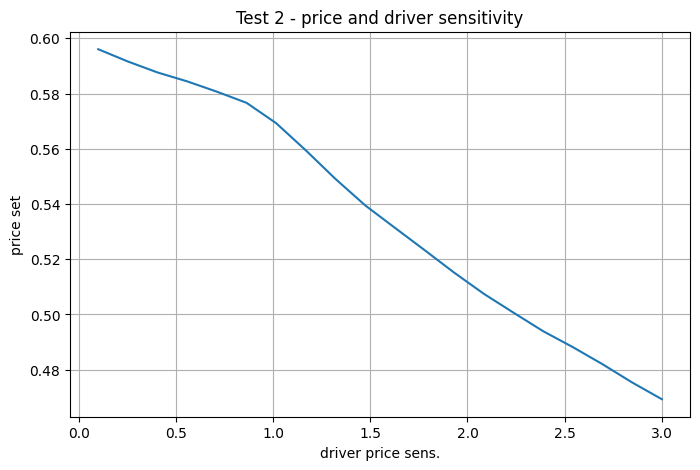

In [35]:
model = PolicyNetwork()
model.load_state_dict(torch.load('new_policy_grad_model_temp_100ep_3layer_window2000.pth'))
model.eval()
prices_passenger = test_passenger_sens()
prices_driver = test_driver_sens()

In [32]:
torch.save(model.state_dict(), 'policy_gradient_temp_2_GOOD.pth')

In [169]:
print(len(all_rewards))

36000


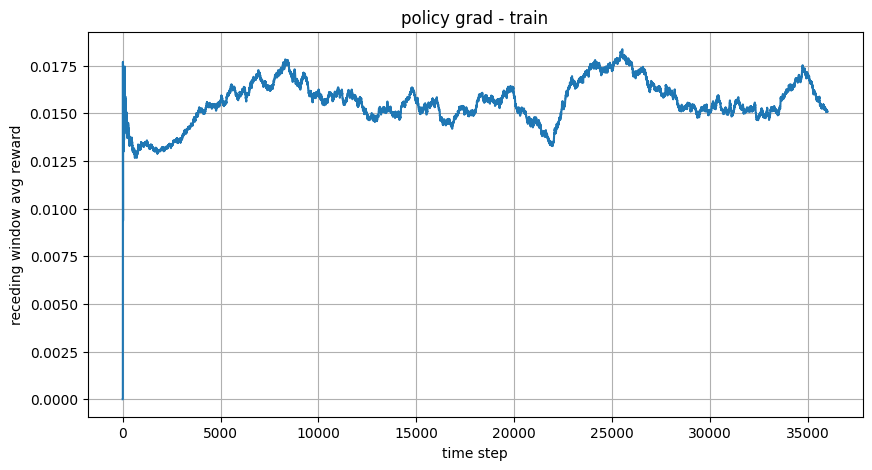

In [170]:
def plot_rewards(all_rewards, window=2000):
    smoothed = []
    for i in range(len(all_rewards)):
        start = max(0, i - window + 1)
        smoothed.append(np.mean(all_rewards[start:i+1]))
    
    plt.figure(figsize=(10, 5))
    plt.plot(smoothed)
    plt.xlabel("time step")
    plt.ylabel("receding window avg reward")
    plt.title("policy grad - train")
    plt.grid(True)
    plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_rewards(all_rewards)

In [36]:
def test_agent_vs_random(episodes=10):
    # test trained agent
    agent_rewards = []
    for ep in range(episodes):
        x, _ = env.reset()
        ep_rewards = []
        for t in range(env.Horizon):
            features = extract_features(x)
            features_tensor = torch.FloatTensor(features)
            with torch.no_grad():
                mu, sigma = model(features_tensor)
                a = torch.sigmoid(mu)  # use mean action, no sampling
            x, reward, done, truncated, info = env.step(a.item())
            ep_rewards.append(reward)
        agent_rewards.append(np.mean(ep_rewards))

    # test random agent
    random_rewards = []
    for ep in range(episodes):
        x, _ = env.reset()
        ep_rewards = []
        for t in range(env.Horizon):
            a = np.random.uniform(0, 1)
            x, reward, done, truncated, info = env.step(a)
            ep_rewards.append(reward)
        random_rewards.append(np.mean(ep_rewards))

    # plot
    plt.figure(figsize=(10, 5))
    plt.plot(agent_rewards, label='Policy Gradient Agent', marker='o')
    plt.plot(random_rewards, label='Random Agent', marker='o')
    plt.axhline(y=np.mean(agent_rewards), color='blue', linestyle='--', alpha=0.5)
    plt.axhline(y=np.mean(random_rewards), color='orange', linestyle='--', alpha=0.5)
    plt.xlabel('episode')
    plt.ylabel('avg reward')
    plt.title('Test 3 - Agent vs Random Baseline')
    plt.legend()
    plt.grid(True)
    plt.savefig('test3_agent_vs_random.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Agent avg: {np.mean(agent_rewards):.4f}")
    print(f"Random avg: {np.mean(random_rewards):.4f}")

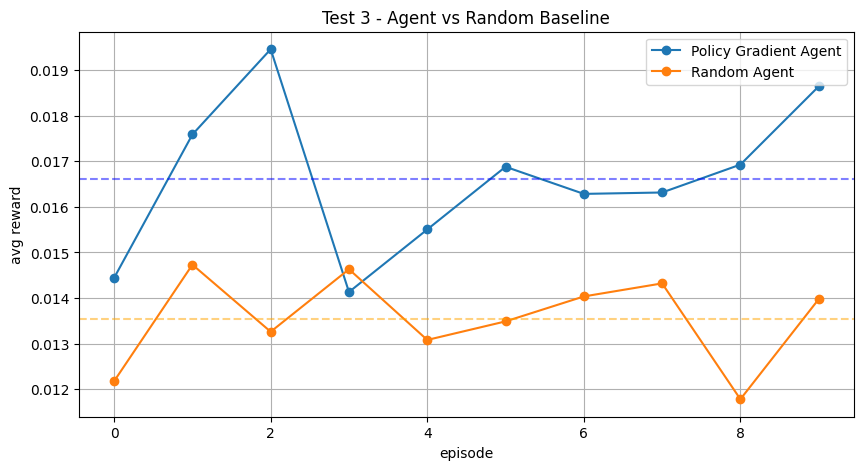

Agent avg: 0.0166
Random avg: 0.0135


In [37]:
model = PolicyNetwork()
model.load_state_dict(torch.load('new_policy_grad_model_temp_100ep_3layer_window2000.pth'))
model.eval()
test_agent_vs_random(episodes=10)